---
title: "Blog 04: Analysis of Pennsylvania Crash Data"
description: "placeholder"
author: "Daniel Park"
date: "2/25/2026"
categories:
  - car crashes
  - data stories
  - data visualization
---

Young people are often described as being more vulnerable on the road. Whether as drivers or cyclists, youth is frequently linked to inexperience, risk-taking behaviour, and higher crash involvement. Over the past five years, I have experienced both a cycling accident and a car accident, which made me question whether that reputation reflects reality or simply perception.

Insurance premiums are higher for younger drivers, licensing systems impose additional restrictions, and safety campaigns consistently target teenagers and young adults. Broader traffic statistics often suggest that drivers in their late teens and early twenties are overrepresented in crash data, particularly in more severe incidents. The implication is clear: being young appears to carry greater risk.

But does this pattern actually hold in Pennsylvania?

In this post, I analyse Pennsylvania crash data to compare young drivers and young cyclists with other age groups. By examining crash frequency and severity across demographics, I aim to determine whether the claim that young road users are statistically more at risk is supported by evidence, or whether the story is more nuanced than it seems.

In [43]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

from shapely.geometry import Point

In [44]:
crash_data = pd.read_csv("data/PDOT_crash_data_2005_2024.csv", low_memory=False)
philly_zip = gpd.read_file("data/philadelphia_zip_boundaries.geojson")
data_dictionary = pd.read_csv('data/data_dictionary.csv')
div_gdf = gpd.read_file("data/Political_Divisions.geojson")
streets = gpd.read_file("data/Street_Centerline.geojson")

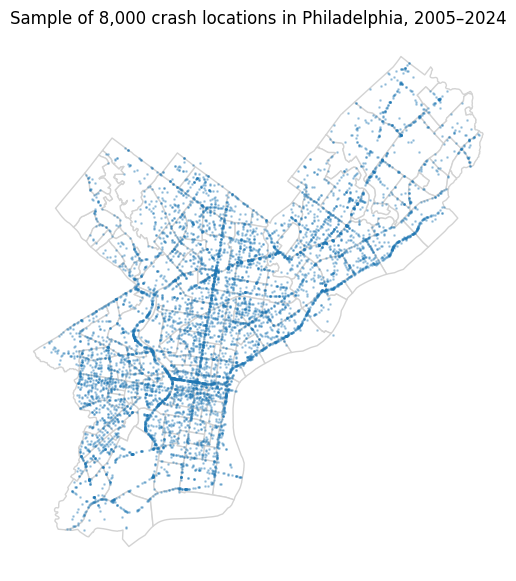

In [42]:
phil_filter = crash_data['COUNTY'] == 67

phil_crashes = crash_data[phil_filter].copy()

# remove rows without decimal coordinates
phil_crashes = phil_crashes.dropna(subset=['DEC_LATITUDE','DEC_LONGITUDE'])

phil_crashes.shape

geom = gpd.points_from_xy(phil_crashes['DEC_LONGITUDE'], phil_crashes['DEC_LATITUDE'])
phil_crashes_gdf = gpd.GeoDataFrame(phil_crashes, geometry=geom).set_crs('EPSG:4326')


philly_zip = gpd.read_file("data/philadelphia_zip_boundaries.geojson")

base = philly_zip.plot(color='white', edgecolor='lightgray', figsize=(7,7))
phil_crashes_gdf.sample(8000).plot(ax=base, markersize=1, alpha=0.3)
base.axis('off')
plt.title("Sample of 8,000 crash locations in Philadelphia, 2005–2024")
plt.show()

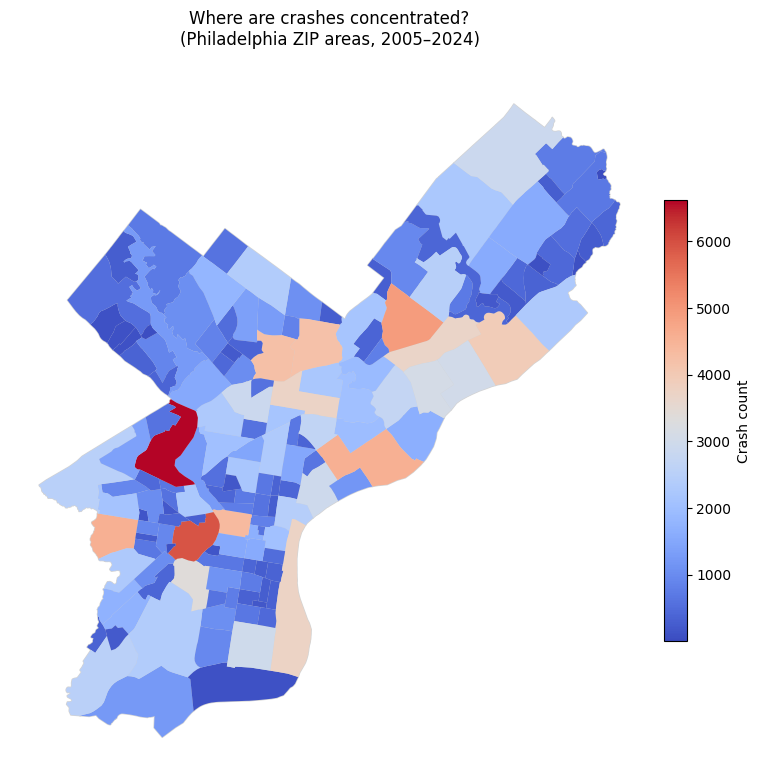

In [6]:
# spatial join: crashes -> zip polygons
zjoin = gpd.sjoin(philly_zip, phil_crashes_gdf, how='left', predicate='contains')

# dissolve by zip and count CRN values
zip_counts = zjoin.dissolve(by='listname', aggfunc={'CRN': 'count'})

# rename to a friendly column name
zip_counts = zip_counts.rename(columns={'CRN': 'crash_count'})

fig, ax = plt.subplots(figsize=(8,8))

philly_zip.plot(ax=ax, color='white', edgecolor='lightgray')

zip_counts.plot(
    ax=ax,
    column='crash_count',
    cmap='coolwarm',   # blue low -> red high
    legend=True,
    legend_kwds={'shrink': 0.6, 'label': 'Crash count', 'pad': 0.02}
)

ax.set_title("Where are crashes concentrated?\n(Philadelphia ZIP areas, 2005–2024)", pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

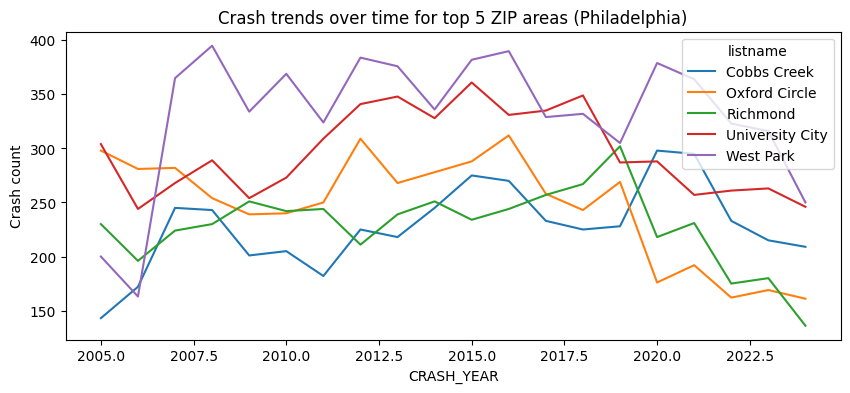

In [7]:
# we want a table with (zip, year) -> crash count
zjoin2 = gpd.sjoin(phil_crashes_gdf, philly_zip[['listname','geometry']], how='left', predicate='within')

zip_year = (
    zjoin2.groupby(['listname','CRASH_YEAR'])
    .size()
    .reset_index(name='crash_count')
)

# choose top 5 ZIP areas overall
top_zips = (
    zip_year.groupby('listname')['crash_count'].sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

zip_year_top = zip_year[zip_year['listname'].isin(top_zips)]

zip_year_pivot = zip_year_top.pivot(index='CRASH_YEAR', columns='listname', values='crash_count').fillna(0)

zip_year_pivot.plot(figsize=(10,4))
plt.title("Crash trends over time for top 5 ZIP areas (Philadelphia)")
plt.ylabel("Crash count")
plt.show()

In [8]:
# rough bounding box (you will tweak)
lat_min, lat_max = 40.02, 40.10
lon_min, lon_max = -75.13, -75.03

roosevelt_box = (
    (phil_crashes_gdf['DEC_LATITUDE'].between(lat_min, lat_max)) &
    (phil_crashes_gdf['DEC_LONGITUDE'].between(lon_min, lon_max))
)

roosevelt_crashes = phil_crashes_gdf[roosevelt_box].copy()
roosevelt_crashes.shape

(30435, 100)

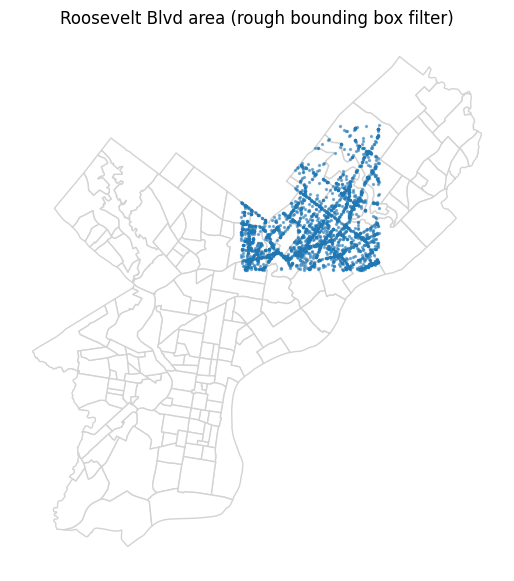

In [9]:
base = philly_zip.plot(color='white', edgecolor='lightgray', figsize=(7,7))
roosevelt_crashes.sample(min(3000, len(roosevelt_crashes))).plot(ax=base, markersize=2, alpha=0.5)
base.axis('off')
plt.title("Roosevelt Blvd area (rough bounding box filter)")
plt.show()

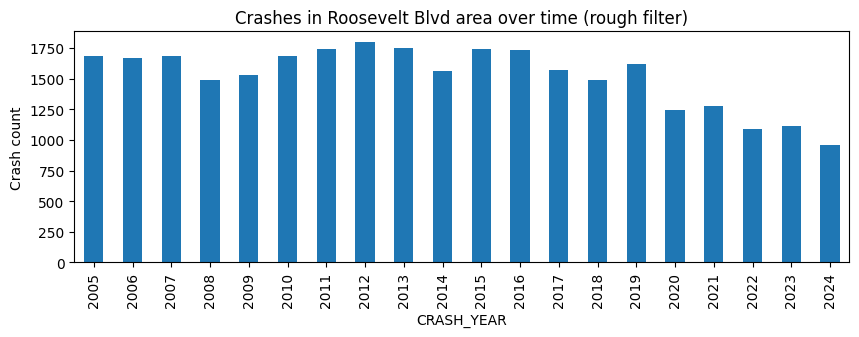

In [10]:
rb_trend = roosevelt_crashes.groupby('CRASH_YEAR').size()

rb_trend.plot(kind='bar', figsize=(10,3))
plt.title("Crashes in Roosevelt Blvd area over time (rough filter)")
plt.ylabel("Crash count")
plt.show()

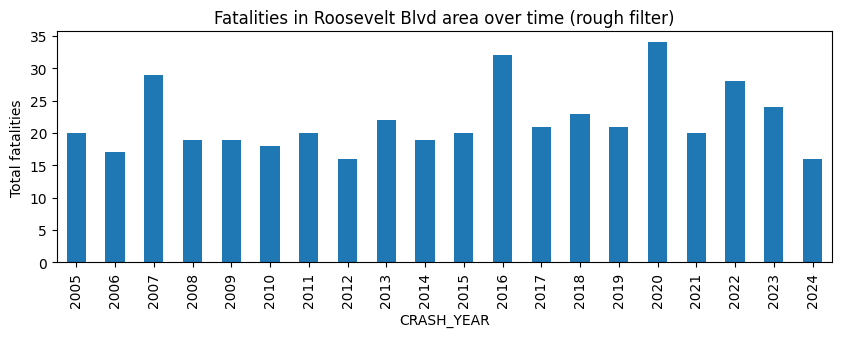

In [11]:
rb_fatal = roosevelt_crashes.groupby('CRASH_YEAR')['FATAL_COUNT'].sum()

rb_fatal.plot(kind='bar', figsize=(10,3))
plt.title("Fatalities in Roosevelt Blvd area over time (rough filter)")
plt.ylabel("Total fatalities")
plt.show()

<Axes: xlabel='period'>

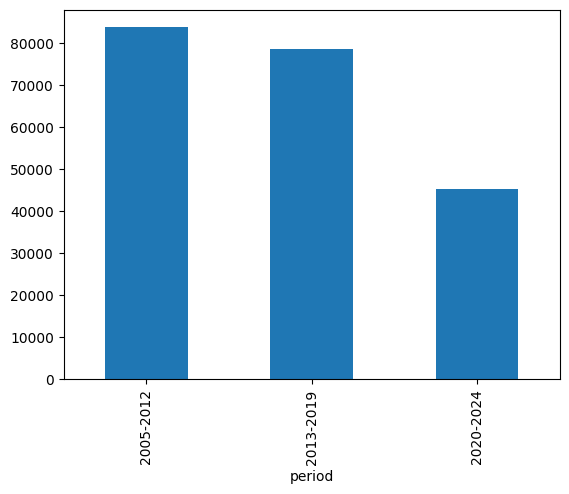

In [13]:
def period(year):
    if year <= 2012:
        return "2005-2012"
    elif year <= 2019:
        return "2013-2019"
    else:
        return "2020-2024"

phil_crashes_gdf['period'] = phil_crashes_gdf['CRASH_YEAR'].apply(period)

period_counts = phil_crashes_gdf.groupby('period').size()
period_counts.plot(kind='bar')

<Axes: xlabel='HOUR_OF_DAY'>

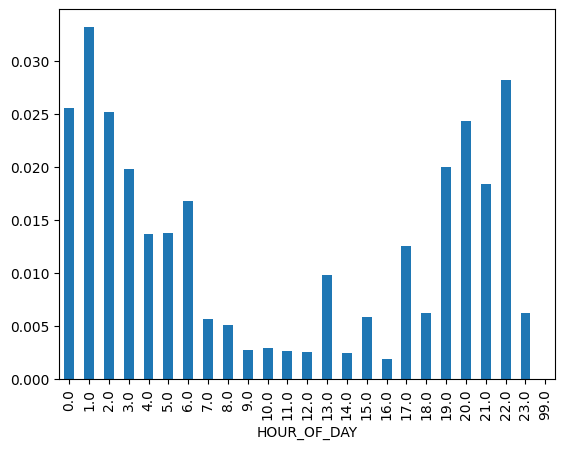

In [15]:
hour_severity = (
    phil_crashes
    .groupby('HOUR_OF_DAY')
    .agg(
        total_crashes=('CRN','count'),
        fatalities=('FATAL_COUNT','sum')
    )
)

hour_severity['fatal_rate'] = hour_severity['fatalities'] / hour_severity['total_crashes']

hour_severity['fatal_rate'].plot(kind='bar')

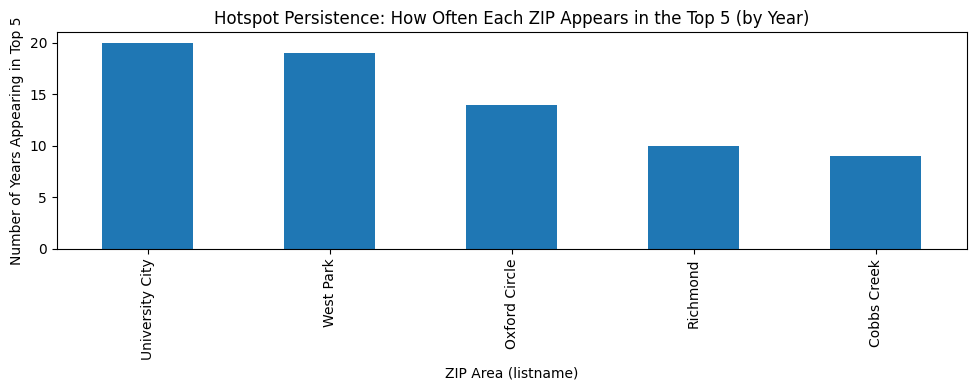

In [26]:
# count crashes per (year, zip)
top_each_year = (
    zjoin.groupby(['CRASH_YEAR', 'listname'])
    .size()
    .reset_index(name='count')
)

# sorting within each year so biggest counts come first
top_each_year = top_each_year.sort_values(['CRASH_YEAR', 'count'], ascending=[True, False])

# taking top 5 ZIP areas per year
top5_each_year = top_each_year.groupby('CRASH_YEAR').head(5)

# finding how many years each ZIP appears in the top 5
hotspot_frequency = top5_each_year['listname'].value_counts()

# finding the top 5 of the ZIPs above.
hotspot_frequency = hotspot_frequency.head(5)

# 5) plot
hotspot_frequency.plot(kind='bar', figsize=(10,4))
plt.title("Hotspot Persistence: How Often Each ZIP Appears in the Top 5 (by Year)")
plt.ylabel("Number of Years Appearing in Top 5")
plt.xlabel("ZIP Area (listname)")
plt.tight_layout()
plt.show()

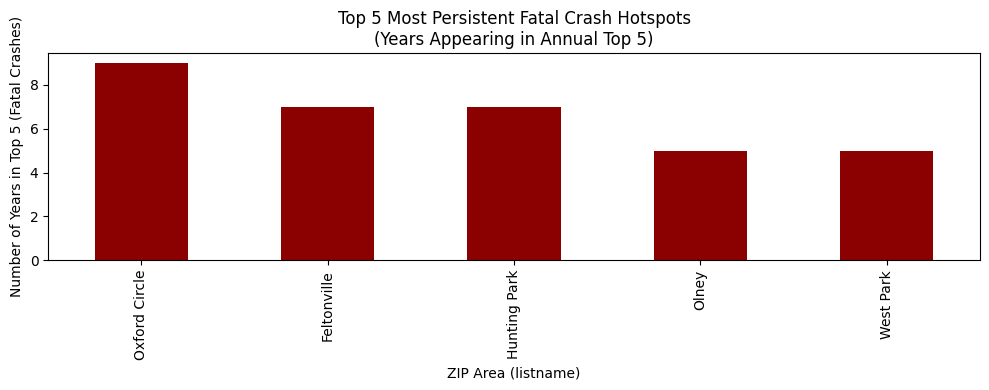

In [25]:
# 1) keep only crashes with at least 1 fatality
fatal_only = zjoin[zjoin['FATAL_COUNT'] > 0].copy()

# 2) count fatal crashes per (year, zip)
fatal_top_each_year = (
    fatal_only.groupby(['CRASH_YEAR', 'listname'])
    .size()
    .reset_index(name='fatal_crash_count')
)

# 3) sort within each year
fatal_top_each_year = fatal_top_each_year.sort_values(
    ['CRASH_YEAR', 'fatal_crash_count'],
    ascending=[True, False]
)

# 4) take top 5 ZIP areas per year
fatal_top5_each_year = fatal_top_each_year.groupby('CRASH_YEAR').head(5)

# 5) count how often each ZIP appears in yearly top 5
fatal_hotspot_frequency = fatal_top5_each_year['listname'].value_counts()

# 6) take top 5 most persistent fatal hotspots
top5_persistent_fatal = fatal_hotspot_frequency.head(5)

# 7) plot
top5_persistent_fatal.plot(kind='bar', figsize=(10,4), color='darkred')

plt.title("Top 5 Most Persistent Fatal Crash Hotspots\n(Years Appearing in Annual Top 5)")
plt.ylabel("Number of Years in Top 5 (Fatal Crashes)")
plt.xlabel("ZIP Area (listname)")
plt.tight_layout()
plt.show()

In [29]:
# filter 2011-2015
period_11_15 = zjoin[
    (zjoin['CRASH_YEAR'] >= 2011) &
    (zjoin['CRASH_YEAR'] <= 2015)
].copy()

# total fatalities by neighborhood
fatal_by_area = (
    period_11_15.groupby('listname')['FATAL_COUNT']
    .sum()
    .sort_values(ascending=False)
)

fatal_by_area.head(15)

listname
West Park           21
Holmesburg          14
Olney               14
Franklinville       14
Oxford Circle       13
Somerton            11
Richmond            11
Northwood           11
Allegheny West      10
Stadium District    10
University City     10
Tacony               9
Pennypack            9
Wissahickon Park     9
Logan                8
Name: FATAL_COUNT, dtype: int64

In [31]:
total_fatalities = period_11_15['FATAL_COUNT'].sum()

share = (
    fatal_by_area / total_fatalities
).sort_values(ascending=False)

share.head(15)

listname
West Park           0.044586
Holmesburg          0.029724
Olney               0.029724
Franklinville       0.029724
Oxford Circle       0.027601
Somerton            0.023355
Richmond            0.023355
Northwood           0.023355
Allegheny West      0.021231
Stadium District    0.021231
University City     0.021231
Tacony              0.019108
Pennypack           0.019108
Wissahickon Park    0.019108
Logan               0.016985
Name: FATAL_COUNT, dtype: float64

In [34]:
# 2011-2015 data
period_11_15 = zjoin[
    (zjoin['CRASH_YEAR'] >= 2011) &
    (zjoin['CRASH_YEAR'] <= 2015)
]

# total city fatalities
total_fatalities = period_11_15['FATAL_COUNT'].sum()

# Kensington grouping
kensington_names = [
    'Kensington, Old',
    'Kensington, West',
    'Upper Kensington',
    'Fishtown - Lower Kensington'
]

kensington_fatal = (
    period_11_15[
        period_11_15['listname'].isin(kensington_names)
    ]['FATAL_COUNT'].sum()
)

kensington_share = kensington_fatal / total_fatalities

kensington_fatal, kensington_share

(np.int64(16), np.float64(0.03397027600849257))

In [35]:
hp_sm_fatal = (
    period_11_15[
        period_11_15['listname'].isin(['Hunting Park','Strawberry Mansion'])
    ]['FATAL_COUNT'].sum()
)

hp_sm_share = hp_sm_fatal / total_fatalities

hp_sm_fatal, hp_sm_share

(np.int64(10), np.float64(0.021231422505307854))

In [36]:
# crash share for same neighborhoods
kensington_crashes = period_11_15[
    period_11_15['listname'].isin(kensington_names)
].shape[0]

hp_sm_crashes = period_11_15[
    period_11_15['listname'].isin(['Hunting Park','Strawberry Mansion'])
].shape[0]

total_crashes = len(period_11_15)

kensington_crash_share = kensington_crashes / total_crashes
hp_sm_crash_share = hp_sm_crashes / total_crashes

kensington_crash_share, hp_sm_crash_share

(0.03748698368622006, 0.025776868411918376)

In [38]:
injury_by_area = (
    period_11_15.groupby('listname')['TOT_INJ_COUNT']
    .sum()
    .sort_values(ascending=False)
)

injury_share = injury_by_area / injury_by_area.sum()
injury_share.head(15)

listname
West Park          0.029180
Oxford Circle      0.029026
University City    0.026926
Olney              0.024279
Cobbs Creek        0.024058
Logan              0.022999
Mayfair            0.020506
Hunting Park       0.019379
Richmond           0.018935
Logan Square       0.017399
Grays Ferry        0.016118
Holmesburg         0.014940
Riverfront         0.014394
Somerton           0.014359
Lawndale           0.014274
Name: TOT_INJ_COUNT, dtype: float64

In [39]:
city_11_15 = phil_crashes_gdf[
    (phil_crashes_gdf['CRASH_YEAR'] >= 2011) &
    (phil_crashes_gdf['CRASH_YEAR'] <= 2015)
].copy()

city_fatalities = city_11_15['FATAL_COUNT'].sum()

# --- 2) Approximate Roosevelt Blvd with a bounding box (quick + notebook-level) ---
# Note: this is a rough proxy; refine later with a real road shapefile/buffer.
rb_bbox = (
    (city_11_15['DEC_LATITUDE'].between(40.02, 40.10)) &
    (city_11_15['DEC_LONGITUDE'].between(-75.13, -75.03))
)

rb_11_15 = city_11_15[rb_bbox].copy()

rb_fatalities = rb_11_15['FATAL_COUNT'].sum()
rb_share = rb_fatalities / city_fatalities

# --- 3) extra stats from the article ---
rb_injuries = rb_11_15['TOT_INJ_COUNT'].sum()
rb_ped_deaths = rb_11_15['PED_DEATH_COUNT'].sum()
rb_ped_share = rb_ped_deaths / rb_fatalities if rb_fatalities > 0 else float('nan')

print("2011–2015 city fatalities:", int(city_fatalities))
print("2011–2015 Roosevelt (bbox) fatalities:", int(rb_fatalities))
print("Roosevelt share of city fatalities:", round(rb_share, 4), f"({rb_share:.1%})")
print("2011–2015 Roosevelt injuries (TOT_INJ_COUNT):", int(rb_injuries))
print("2011–2015 Roosevelt pedestrian deaths:", int(rb_ped_deaths))
print("Pedestrian share of Roosevelt deaths:", round(rb_ped_share, 4), f"({rb_ped_share:.1%})")


2011–2015 city fatalities: 472
2011–2015 Roosevelt (bbox) fatalities: 97
Roosevelt share of city fatalities: 0.2055 (20.6%)
2011–2015 Roosevelt injuries (TOT_INJ_COUNT): 9933
2011–2015 Roosevelt pedestrian deaths: 42
Pedestrian share of Roosevelt deaths: 0.433 (43.3%)


In [48]:
roosevelt = streets[
    streets['st_name'].str.contains('Roosevelt', case=False, na=False)
].copy()

roosevelt[['st_name', 'st_type']].drop_duplicates()

,st_name,st_type
22545,ROOSEVELT,BLVD
23419,ROOSEVELT BLVD,RAMP


In [50]:
# main boulevard segments
rb_main = streets[
    (streets['st_name'].str.upper().eq('ROOSEVELT')) &
    (streets['st_type'].str.upper().eq('BLVD'))
].copy()

# ramps (optional)
rb_ramps = streets[
    (streets['st_name'].str.upper().str.contains('ROOSEVELT', na=False)) &
    (streets['st_type'].str.upper().eq('RAMP'))
].copy()

# combine (main + ramps)
rb_all = pd.concat([rb_main, rb_ramps], ignore_index=True)

In [52]:
rb_main = rb_main.to_crs(epsg=2272)
rb_all  = rb_all.to_crs(epsg=2272)

buffer_ft = 100  # try 50, 100, 150 later as a sensitivity check

rb_main_buf = gpd.GeoDataFrame(geometry=rb_main.buffer(buffer_ft), crs=rb_main.crs)
rb_all_buf  = gpd.GeoDataFrame(geometry=rb_all.buffer(buffer_ft),  crs=rb_all.crs)

In [53]:
city_11_15 = phil_crashes_gdf[
    (phil_crashes_gdf['CRASH_YEAR'] >= 2011) &
    (phil_crashes_gdf['CRASH_YEAR'] <= 2015)
].copy()

city_11_15 = city_11_15.to_crs(epsg=2272)

city_fatalities = city_11_15['FATAL_COUNT'].sum()

In [54]:
def stats_for_buffer(buf_gdf, label):
    joined = gpd.sjoin(city_11_15, buf_gdf, predicate='within')
    joined = joined.drop_duplicates(subset=['CRN'])  # avoid double-counting

    rb_fatalities = joined['FATAL_COUNT'].sum()
    rb_share = rb_fatalities / city_fatalities if city_fatalities else float('nan')

    rb_injuries = joined['TOT_INJ_COUNT'].sum()
    rb_ped_deaths = joined['PED_DEATH_COUNT'].sum()
    rb_ped_share = (rb_ped_deaths / rb_fatalities) if rb_fatalities else float('nan')

    print(f"\n--- {label} ---")
    print("Crashes matched:", len(joined))
    print("Fatalities:", int(rb_fatalities))
    print("Share of city fatalities:", round(rb_share, 4), f"({rb_share:.1%})")
    print("Injuries (TOT_INJ_COUNT):", int(rb_injuries))
    print("Pedestrian deaths:", int(rb_ped_deaths))
    print("Pedestrian share of deaths:", round(rb_ped_share, 4), f"({rb_ped_share:.1%})")

stats_for_buffer(rb_main_buf, "Roosevelt BLVD (main only)")
stats_for_buffer(rb_all_buf,  "Roosevelt (main + ramps)")


--- Roosevelt BLVD (main only) ---
Crashes matched: 3579
Fatalities: 64
Share of city fatalities: 0.1356 (13.6%)
Injuries (TOT_INJ_COUNT): 4416
Pedestrian deaths: 22
Pedestrian share of deaths: 0.3438 (34.4%)

--- Roosevelt (main + ramps) ---
Crashes matched: 3606
Fatalities: 65
Share of city fatalities: 0.1377 (13.8%)
Injuries (TOT_INJ_COUNT): 4445
Pedestrian deaths: 22
Pedestrian share of deaths: 0.3385 (33.8%)


In [55]:
def roosevelt_stats(crash_subset, buffer_gdf):
    joined = gpd.sjoin(crash_subset, buffer_gdf, predicate='within')
    joined = joined.drop_duplicates(subset=['CRN'])
    
    rb_fatal = joined['FATAL_COUNT'].sum()
    city_fatal = crash_subset['FATAL_COUNT'].sum()
    
    share = rb_fatal / city_fatal if city_fatal > 0 else float('nan')
    
    return rb_fatal, city_fatal, share

In [56]:
# project entire crash dataset once
all_crashes = phil_crashes_gdf.to_crs(epsg=2272)

pre = all_crashes[(all_crashes['CRASH_YEAR'] >= 2011) & (all_crashes['CRASH_YEAR'] <= 2019)]
post = all_crashes[(all_crashes['CRASH_YEAR'] >= 2020) & (all_crashes['CRASH_YEAR'] <= 2024)]

pre_stats = roosevelt_stats(pre, rb_all_buf)
post_stats = roosevelt_stats(post, rb_all_buf)

print("Pre-2020 (2011–2019)")
print("Roosevelt fatalities:", pre_stats[0])
print("City fatalities:", pre_stats[1])
print("Share:", round(pre_stats[2],4), f"({pre_stats[2]:.1%})")

print("\nPost-2020 (2020–2024)")
print("Roosevelt fatalities:", post_stats[0])
print("City fatalities:", post_stats[1])
print("Share:", round(post_stats[2],4), f"({post_stats[2]:.1%})")

Pre-2020 (2011–2019)
Roosevelt fatalities: 119
City fatalities: 861
Share: 0.1382 (13.8%)

Post-2020 (2020–2024)
Roosevelt fatalities: 52
City fatalities: 713
Share: 0.0729 (7.3%)


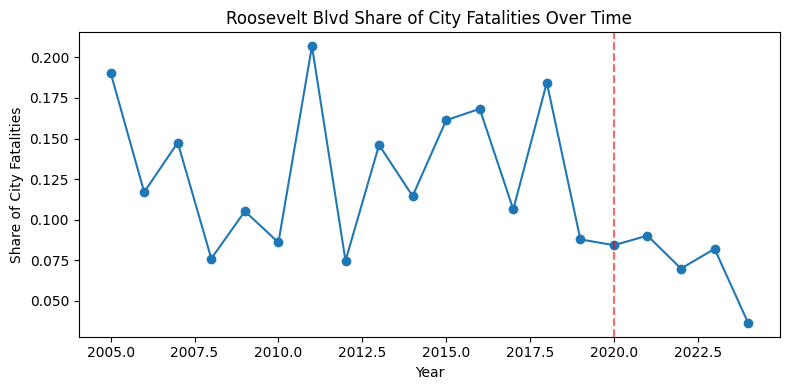

In [58]:
years = sorted(all_crashes['CRASH_YEAR'].unique())

year_results = []

for y in years:
    subset = all_crashes[all_crashes['CRASH_YEAR'] == y]
    rb_fatal, city_fatal, share = roosevelt_stats(subset, rb_all_buf)
    year_results.append([y, rb_fatal, city_fatal, share])

import pandas as pd
year_df = pd.DataFrame(year_results, columns=['year','rb_fatal','city_fatal','share'])

year_df

plt.figure(figsize=(8,4))
plt.plot(year_df['year'], year_df['share'], marker='o')
plt.axvline(2020, linestyle='--', color='red', alpha=0.6)
plt.title("Roosevelt Blvd Share of City Fatalities Over Time")
plt.ylabel("Share of City Fatalities")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

### Legal firms citing crash data


> Roosevelt Boulevard, Philadelphia, Pennsylvania
> 
> While the other roads mentioned on this list are highways, Roosevelt Boulevard in Philadelphia is included because of its notoriety as one of the most dangerous thoroughfares in America. The boulevard consists of six 12-foot wide lanes in each direction, and drivers regularly exceed the posted 45 miles per hour and take the road’s dangerous curves far too fast. The boulevard also has two of the nation’s most dangerous intersections, where confused drivers frequently turn into the wrong three-lane stretch of traffic.

https://www.hg.org/legal-articles/5-of-the-most-dangerous-roads-in-the-u-s--32057

> Pennsylvania roads are dangerous, and with its large concentration of population, Philadelphia has the greatest number of crash-related deaths. In fact, according to PennDOT data on fatal car accidents, Philadelphia had more than a quarter of the road segments that were among the state’s most deadly from 2015-2017. During this period, Philly had 24 road segments with 155 total fatal collisions, leading to 167 deaths. This amounted to about a third of the segments with at least four deaths in the entire state.

https://www.wnwlaw.com/philly-four-pennsylvanias-ten-deadliest-roads/


* Study by law firm

https://www.dallashartman.com/blog/2019/01/deadly-roads-pa/